In [4]:
import numpy as np
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy import optimize
from matplotlib import cycler
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# **Formulas**

Stieltjes Transforms and $\xi$ self-consistency

In [5]:
def M_kappa_nu_empirical(kappa, nu, Ctr, numavg=10):
  d = len(Ctr)
  estimate = 0
  for _ in range(numavg):
    samples = np.random.multivariate_normal(np.zeros(d), Ctr, int(d*kappa)).T;
    samplecov = (samples@samples.T)/int(d*kappa)
    estimate = estimate + (1/d)*np.trace(np.linalg.inv(samplecov + nu*np.eye(d)))
  estimate = estimate/numavg
  return estimate

def M2_kappa_nu_empirical(kappa, nu, Ctr):
  d = len(Ctr)
  estimate = 0
  numavg = 500
  for _ in range(numavg):
    samples = np.random.multivariate_normal(np.zeros(d), Ctr, int(d*kappa)).T;
    samplecov = (samples@samples.T)/int(d*kappa)
    estimate = estimate + (1/d)*np.trace(np.linalg.inv((samplecov + nu*np.eye(d))@(samplecov + nu*np.eye(d))))
  estimate = estimate/numavg
  return estimate

def M_M2_empirical(kappa, nu, Ctr, numavg=10):
    d = len(Ctr)
    estimate1 = 0; estimate2 = 0;
    for _ in range(numavg):
        samples = np.random.multivariate_normal(np.zeros(d), Ctr, int(d*kappa)).T;
        samplecov = (samples@samples.T)/int(d*kappa)
        R = np.linalg.inv(samplecov + nu*np.eye(d))
        estimate1 += (1/d)*np.trace(R)
        estimate2 += (1/d)*np.trace(R@R)
    estimate1 = estimate1/numavg; estimate2 = estimate2/numavg;
    return estimate1, estimate2

def M_kappa(nu, kappa, c):
    # Ctr = c*I
    return 2 / ( (nu + c - c/kappa) + np.sqrt((nu + c - c/kappa)**2 + 4*c*nu/kappa) )

def M_kappa_prime(nu, kappa, c):
    M = M_kappa(nu, kappa, c)
    return (-1/2) * M**2 * (1 + (nu + c + c/kappa)/np.sqrt((nu + c - c/kappa)**2 + 4*c*nu/kappa))

def objectivefunc(xi, tau, kappa, Ctr, rhotr_alpha):
    return xi*M_kappa_nu_empirical(kappa, xi + rhotr_alpha, Ctr) + tau - 1
def xi_tau_less_1(tau, kappa, Ctr, rhotr_alpha):
    leftbound = 0
    rightbound = 2*rhotr_alpha*tau
    while objectivefunc(rightbound, tau, kappa, Ctr, rhotr_alpha) < 0:
        rightbound = rightbound+1
    root = optimize.brentq(objectivefunc, leftbound, rightbound, args=(tau, kappa, Ctr, rhotr_alpha))
    return root

Various ICL errors

In [6]:
def ICL_error(Ctr, Ctesthat, tau, alpha, kappa, rho, numavg=10):
    d = len(Ctr)
    rhotr = (1/d)*np.trace(Ctr) + rho
    rhotest = (1/d)*np.trace(Ctesthat) + rho;

    if tau == 1:
        return None
    if tau > 1:
        xi = 0
    if tau < 1:
        xi = xi_tau_less_1(tau, kappa, Ctr, rhotr/alpha)

    nu = rhotr/alpha + xi
    M, M2 = M_M2_empirical(kappa, nu, Ctr, numavg); Mprime = -M2;
    FR = np.linalg.inv((1 - 1/kappa + (nu/kappa)*M)*Ctr + nu*np.eye(d))
    FR2 = FR @ (((1/kappa)*M + (nu/kappa)*Mprime)*Ctr + np.eye(d)) @ FR

    idg = (rho + nu - (nu**2)*M - xi*(1 - 2*nu*M - (nu**2)*Mprime))/(tau - (1 - 2*xi*M - (xi**2)*Mprime))
    pretraining_term = rho + (rhotest/alpha)*(1 + (idg-2*nu)*M + (xi*idg - nu**2)*Mprime)
    interaction_term = idg*(1/d)*np.trace(Ctesthat@FR) - (idg*xi - nu**2)*(1/d)*np.trace(Ctesthat@FR2)
    return pretraining_term+interaction_term

def ICL_error_testalphas(Ctr, Ctesthat, tau, alpha, kappa, rho, alphatestarray, numavg=10):
    d = len(Ctr)
    rhotr = (1/d)*np.trace(Ctr) + rho
    rhotest = (1/d)*np.trace(Ctesthat) + rho;

    if tau == 1:
        return None
    if tau > 1:
        xi = 0
    if tau < 1:
        xi = xi_tau_less_1(tau, kappa, Ctr, rhotr/alpha)

    nu = rhotr/alpha + xi
    M, M2 = M_M2_empirical(kappa, nu, Ctr, numavg); Mprime = -M2;
    FR = np.linalg.inv((1 - 1/kappa + (nu/kappa)*M)*Ctr + nu*np.eye(d))
    FR2 = FR @ (((1/kappa)*M + (nu/kappa)*Mprime)*Ctr + np.eye(d)) @ FR

    idg = (rho + nu - (nu**2)*M - xi*(1 - 2*nu*M - (nu**2)*Mprime))/(tau - (1 - 2*xi*M - (xi**2)*Mprime))
    interaction_term = idg*(1/d)*np.trace(Ctesthat@FR) - (idg*xi - nu**2)*(1/d)*np.trace(Ctesthat@FR2)
    return [rho + (rhotest/TESTINGALPHA)*(1 + (idg-2*nu)*M + (xi*idg - nu**2)*Mprime) + interaction_term for TESTINGALPHA in alphatestarray]

def ICL_error_Ctronly(Ctr, tau, alpha, kappa, rho, numavg=10):
    d = len(Ctr)
    rhotr = (1/d)*np.trace(Ctr) + rho

    if tau == 1:
        return None
    if tau > 1:
        xi = 0
    if tau < 1:
        xi = xi_tau_less_1(tau, kappa, Ctr, rhotr/alpha)

    nu = rhotr/alpha + xi
    M, M2 = M_M2_empirical(kappa, nu, Ctr, numavg); Mprime = -M2;

    idg = (rho + nu - (nu**2)*M - xi*(1 - 2*nu*M - (nu**2)*Mprime))/(tau - (1 - 2*xi*M - (xi**2)*Mprime))
    pretraining_term = rho + (rhotr/alpha)*(1 + (idg-2*nu)*M + (xi*idg - nu**2)*Mprime)
    A = 1 - (1/kappa)*(1-nu*M)
    B = (1/kappa)*M + (nu/kappa)*Mprime
    interaction_term = idg*(1-nu*M)/A - (idg*xi - nu**2)*(M+nu*Mprime)/(A**2)
    return pretraining_term+interaction_term

def ealign(Ctr, Ctesthat, tau, alpha, kappa, rho, numavg=10):
    d = len(Ctr)
    rhotr = (1/d)*np.trace(Ctr) + rho
    rhotest = (1/d)*np.trace(Ctesthat) + rho;

    if tau == 1:
        return None
    if tau > 1:
        xi = 0
    if tau < 1:
        xi = xi_tau_less_1(tau, kappa, Ctr, rhotr/alpha)

    nu = rhotr/alpha + xi
    M, M2 = M_M2_empirical(kappa, nu, Ctr, numavg); Mprime = -M2;
    FR = np.linalg.inv((1 - 1/kappa + (nu/kappa)*M)*Ctr + nu*np.eye(d))
    FR2 = FR @ (((1/kappa)*M + (nu/kappa)*Mprime)*Ctr + np.eye(d)) @ FR

    idg = (rho + nu - (nu**2)*M - xi*(1 - 2*nu*M - (nu**2)*Mprime))/(tau - (1 - 2*xi*M - (xi**2)*Mprime))
    interaction_term = idg*(1/d)*np.trace(Ctesthat@FR) - (idg*xi - nu**2)*(1/d)*np.trace(Ctesthat@FR2)
    return interaction_term

def icl_scaled_isotropic(tau, alpha_tr, alpha_test, kappa, rho, ctr, ctest):
    if tau == 1:
        return None
    if tau > 1:
        xi = 0
        nu = (rho + ctr)/alpha_tr
    if tau < 1:
        xi = ((1-tau)/tau)/M_kappa((rho + ctr)/alpha_tr, kappa/tau, ctr)
        nu = (rho + ctr)/alpha_tr + xi

    M = M_kappa(nu, kappa, ctr)
    Mprime = M_kappa_prime(nu,kappa,ctr)
    zero = ctest + rho
    linear = ctest*(1 - nu*M)
    quadratic_eq = ((ctest+rho)/alpha_test + ctest)*(1 - 2*nu*M - (nu**2)*Mprime)
    c_e = ((rho + ctr) - (ctr-nu+(nu**2)*M) - xi*(1 - 2*nu*M - (nu**2)*Mprime))/(1 - 2*xi*M - (xi**2)*Mprime - tau)
    quadratic_extra = -c_e * ((ctest+rho)/alpha_test + ctest) * (M + xi*Mprime)
    return zero -2*linear + quadratic_eq + quadratic_extra

def test_alignment_positive_definite_isotropic(tau, alpha_tr, kappa, rho, ctr):
    if tau == 1:
        return None
    if tau > 1:
        xi = 0
        nu = (rho + ctr)/alpha_tr
    if tau < 1:
        xi = ((1-tau)/tau)/M_kappa((rho + ctr)/alpha_tr, kappa/tau, ctr)
        nu = (rho + ctr)/alpha_tr + xi

    M = M_kappa(nu, kappa, ctr)
    Mprime = M_kappa_prime(nu,kappa,ctr)

    d = 20
    FR = 1/((1 - 1/kappa + (nu/kappa)*M)*ctr + nu)
    FR2 = (((1/kappa)*M + (nu/kappa)*Mprime)*ctr + 1)*FR*FR

    A = (1 - 1/kappa + (nu/kappa)*M)
    B = ((1/kappa)*M + (nu/kappa)*Mprime)

    idg = (rho + nu - (nu**2)*M - xi*(1 - 2*nu*M - (nu**2)*Mprime))/(tau - (1 - 2*xi*M - (xi**2)*Mprime))
    G = (idg*FR - (idg*xi - nu**2)*FR2)*np.eye(d)
    return A - xi*B 

def prop_icl(tau, alpha, kappa, rho):
    q = (1 + rho) / alpha
    m = M_kappa(q, kappa, 1)
    M = M_kappa_prime(q, kappa, 1)
    mu = q * M_kappa(q, kappa/tau, 1)

    if tau < 1:
        result = (tau * (1 + q) / (1 - tau)) * (1 - tau * (1 - mu)**2 + mu*((rho/q - 1)) ) - 2 * tau * (1 - mu) + rho + 1
    else:
        result = (1+q)*(1-2*q*m-(q**2)*M + (m/(tau-1))*(rho+q-(q**2)*m))-2*(1-q*m) + 1 + rho
    return result

Various IDG Errors

In [7]:
def IDG_error(Ctr, tau, alpha, kappa, rho, numavg=20):
    d = len(Ctr)
    rhotr = (1/d)*np.trace(Ctr) + rho

    if tau == 1:
        return None
    if tau > 1:
        xi = 0
    if tau < 1:
        xi = xi_tau_less_1(tau, kappa, Ctr, rhotr/alpha)

    nu = rhotr/alpha + xi
    M, M2 = M_M2_empirical(kappa, nu, Ctr, numavg); Mprime = -M2;
    return tau*(rho + nu - (nu**2)*M - xi*(1 - 2*nu*M - (nu**2)*Mprime))/(tau - (1 - 2*xi*M - (xi**2)*Mprime))

def prop_idg(tau, alpha, kappa, rho):
  Xstar = (1 + rho)/alpha
  mstar = 2/(Xstar + 1 - 1/kappa + np.sqrt(4*Xstar/kappa + (Xstar + 1 - 1/kappa)**2))
  mustar = 2*Xstar/(Xstar + 1 - tau/kappa + np.sqrt(4*Xstar*tau/kappa + (Xstar + 1 - tau/kappa)**2))

  answer = 0;
  if tau < 1:
    eps = (1-tau)*Xstar/(tau*mustar)
    c = 1/(1 - kappa/(1+kappa*eps/(1-tau))**2)
    answer = (Xstar + eps)**2/eps + (rho+Xstar-2*Xstar*(1-tau)*(Xstar/eps + 1))/(1-tau-c*(1-tau)**2)
  else:
    answer = (rho + Xstar*(1-Xstar*mstar))/(tau-1)
  return tau*answer

def idg_scaled_isotropic(tau, alpha, kappa, rho, ctr):
    if tau == 1:
        return None
    if tau > 1:
        xi = 0
        nu = (rho + ctr)/alpha
    if tau < 1:
        xi = ((1-tau)/tau)/M_kappa((rho + ctr)/alpha, kappa/tau, ctr)
        nu = (rho + ctr)/alpha + xi

    M = M_kappa(nu, kappa, ctr)
    Mprime = M_kappa_prime(nu,kappa,ctr)

    return tau*(rho + nu - (nu**2)*M - xi*(1 - 2*nu*M - (nu**2)*Mprime))/(tau - (1 - 2*xi*M - (xi**2)*Mprime))

# **Heatmap of kappa vs power difference**

In [16]:
d = 100
test_power = 0.9
alpha = 1
tau = 4
rho = 0.01
kappas = np.linspace(0.1,2.1,81)
powers = np.linspace(test_power-0.5, test_power+2, 51)
Ctest = np.diag(np.array([(j + 1) ** -test_power for j in range(d)])); Ctest = (Ctest/np.trace(Ctest))*d
matched_train_test = np.array([ICL_error(Ctest, Ctest, tau, alpha, kappa, rho, numavg=20) for kappa in kappas])

vals = np.zeros((len(powers),len(kappas)))
for i in tqdm(range(len(powers))):
    powertrain = powers[i]
    Ctr = np.diag(np.array([(j + 1) ** -powertrain for j in range(d)])); Ctr = (Ctr/np.trace(Ctr))*d
    diff = (np.array([ICL_error(Ctr, Ctest, tau, alpha, kappa, rho, numavg=20) for kappa in kappas])-matched_train_test)/matched_train_test
    vals[i,:] = diff

100%|██████████| 51/51 [01:31<00:00,  1.79s/it]


In [17]:
# DEFINE STANDARD FORMATING FOR FIGURES USED THROUGHOUT PAPER
sns.set(style="white",font_scale=1.5,palette="colorblind")
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams["figure.figsize"] = (24, 20)

# Create a custom  colormap from light to dark cyan
import matplotlib.colors as matcolors 
cyans = matcolors.LinearSegmentedColormap.from_list("what", ["#E8FDFB","#40E0D0", "#0AA192"])#["#E8FDFB", "#40E0D0", "#2AC6B6"])

Text(58.25, 0.5, 'Train power $-$ Test power')

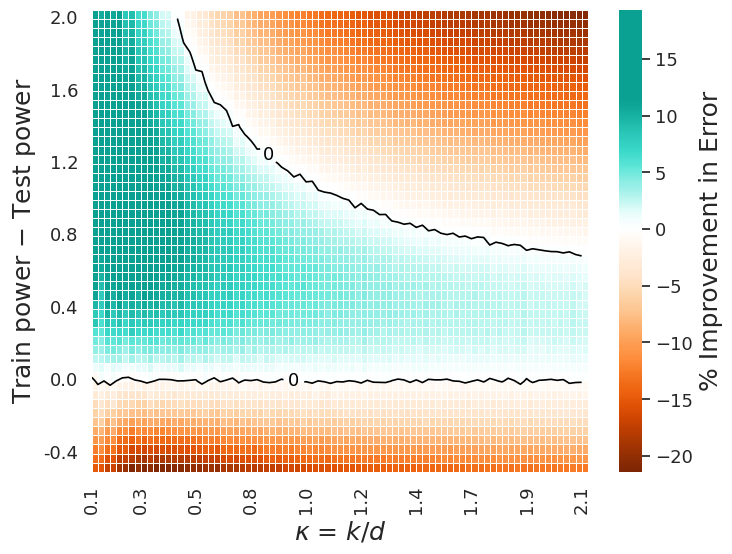

In [18]:
sample = 15
colors = np.vstack(
    (
        # Default is White -> Green but I want Green -> White -> Red so reverse the order
        plt.get_cmap("Oranges", sample)(np.linspace(0, 1, sample))[::-1],
        np.ones((1, 4)),
        cyans(np.linspace(0, 2, sample)),
        # np.ones((1, 4)),  # Explicit White optional
    )
)
cmap_mary = LinearSegmentedColormap.from_list("green_to_red", colors)

rows = powers - test_power #round_to_sig_figs(index_eignfuncs, 1)
columns = kappas

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

# Create heatmap
sns.heatmap(-100*vals,
            yticklabels=np.linspace(0, len(rows) - 1, 20, dtype=int),
            xticklabels=np.linspace(0, len(columns) - 1, 20, dtype=int),  # Select 10 evenly spaced indices
            center=0,
            cmap = cmap_mary,
            annot=False,
            linewidths=0.5,
            cbar=True,
            ax=ax,
            cbar_kws={'label': '% Improvement in Error'})

KAPPA, DELTA = np.meshgrid(np.arange(len(kappas)), np.arange(len(powers -  test_power)))
contours = ax.contour(KAPPA, DELTA, -100*vals, levels=[0], colors='black', linewidths=1.2)
labels = ax.clabel(contours, fmt='%1.0f', fontsize=13, inline=True)
for txt in labels:
    txt.set_rotation(0)  # force horizontal orientation

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=13)

# Adjust tick labels
ax.set_xticks(np.linspace(0, len(columns) - 1, 10, dtype=int))
ax.set_xticklabels([f"{val:.1f}" for val in columns[np.linspace(0, len(columns) - 1, 10, dtype=int)]], rotation = 90, fontsize=13)

ax.set_yticks(np.linspace(2, len(rows)-1, 7, dtype=int))
ax.set_yticklabels([f"{val:.1f}" for val in rows[np.linspace(2, len(rows)-1, 7, dtype=int)]], fontsize=13)
ax.invert_yaxis()

# Labels
ax.set_xlabel(r"$\kappa$ = $k/d$")
ax.set_ylabel(r"Train power $-$ Test power")